# TF-IDF model


In [11]:
import matplotlib.pyplot as plt
from src.data.processor import unzip_data_extract_contents
from src.model.train_model import train_tfidf_logreg
from src.model.predict_model import predict_sentiment_tfidf

test_archive, train_archive, unsup_archive, imdb_vocab, imdb_expected_rating = unzip_data_extract_contents()
train_tfidf_logreg(test_archive, train_archive, imdb_vocab, imdb_expected_rating)

reviews = [
        "this movie was great and the acting was amazing",
        "this movie was mid"]
for review in reviews:
    print("TF-IDF Prediction:", predict_sentiment_tfidf(review))
    print("TF-IDF Prediction with best params:", predict_sentiment_tfidf(review, with_params=True))

              precision    recall  f1-score   support

         neg       0.88      0.88      0.88     12500
         pos       0.88      0.88      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000

Classification report with best params:
              precision    recall  f1-score   support

         neg       0.88      0.88      0.88     12500
         pos       0.88      0.88      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000

TF-IDF Prediction: pos
TF-IDF Prediction with best params: pos
TF-IDF Prediction: neg
TF-IDF Prediction with best params: neg


In [7]:
import random

SAMPLE_SIZE = 2000

pos_reviews = [r for r in test_archive.reviews if r['type'] == 'pos']
neg_reviews = [r for r in test_archive.reviews if r['type'] == 'neg']

test_sample = random.sample(pos_reviews, SAMPLE_SIZE//2) + random.sample(neg_reviews, SAMPLE_SIZE//2)
train_sample = random.sample([r for r in train_archive.reviews if r['type'] == 'pos'], SAMPLE_SIZE//2) + \
               random.sample([r for r in train_archive.reviews if r['type'] == 'neg'], SAMPLE_SIZE//2)

print(f"Using balanced sample of {SAMPLE_SIZE} reviews")

Using balanced sample of 2000 reviews


### Confusion Matrix Comparison
The confusion matrix shows how well each TF-IDF model predicts positive and negative sentiment. The diagonal values represent correct predictions while off-diagonal values show misclassifications. The Default model shows the baseline performance using standard logistic regression parameters. The Tuned model uses optimized hyperparameters found through grid search. Both matrices help identify if the model has bias toward predicting one class over another. Higher numbers on the diagonal indicate better performance.


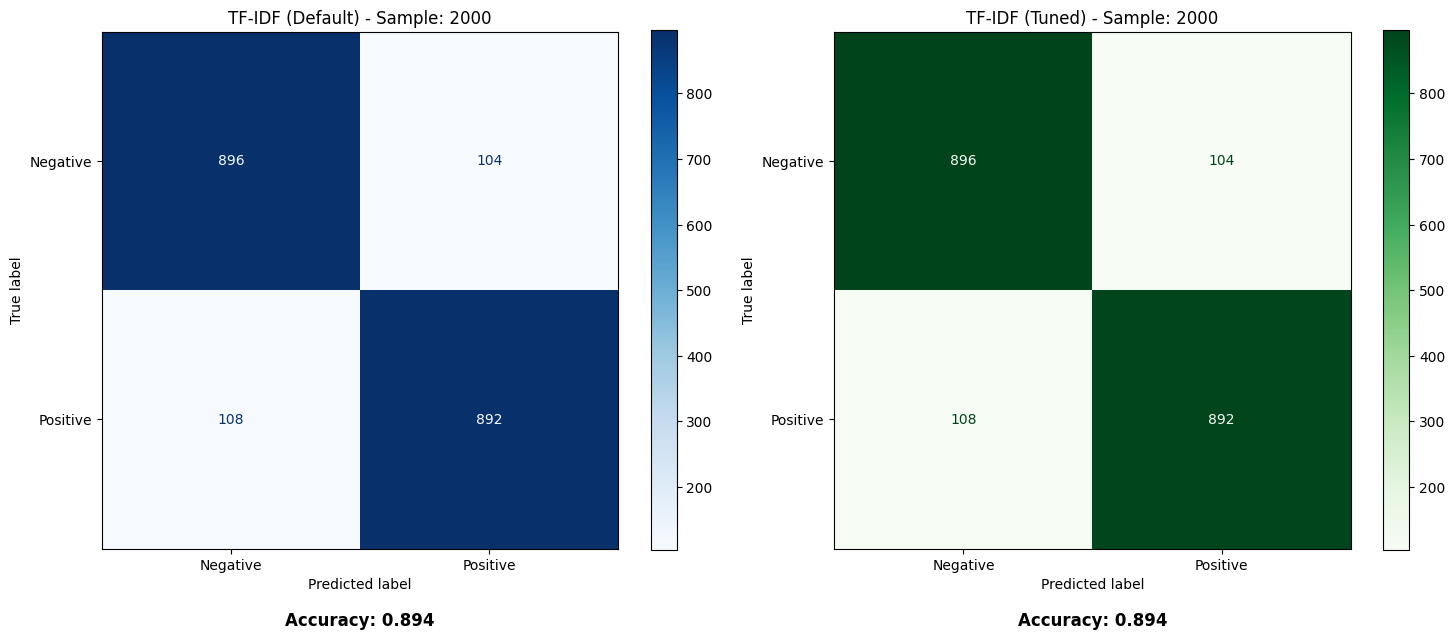

Default Model Accuracy: 0.894
Tuned Model Accuracy:   0.894
Improvement:            +0.000


In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
label_map = {'neg': 0, 'pos': 1}

y_test_pred_default = [predict_sentiment_tfidf(r['contents'], with_params=False) 
                       for r in test_sample]
y_test_true = [r['type'] for r in test_sample]
y_true_num = [label_map[y] for y in y_test_true]
y_pred_num_default = [label_map[y] for y in y_test_pred_default]

cm_default = confusion_matrix(y_true_num, y_pred_num_default)
disp_default = ConfusionMatrixDisplay(confusion_matrix=cm_default, display_labels=['Negative', 'Positive'])
disp_default.plot(ax=ax1, cmap=plt.cm.Blues)
ax1.set_title(f'TF-IDF (Default) - Sample: {len(test_sample)}')

accuracy_default = sum([yt == yp for yt, yp in zip(y_test_true, y_test_pred_default)]) / len(y_test_true)
ax1.text(0.5, -0.15, f'Accuracy: {accuracy_default:.3f}', transform=ax1.transAxes, 
         ha='center', fontsize=12, fontweight='bold')

y_test_pred_tuned = [predict_sentiment_tfidf(r['contents'], with_params=True) 
                     for r in test_sample]
y_pred_num_tuned = [label_map[y] for y in y_test_pred_tuned]

cm_tuned = confusion_matrix(y_true_num, y_pred_num_tuned)
disp_tuned = ConfusionMatrixDisplay(confusion_matrix=cm_tuned, display_labels=['Negative', 'Positive'])
disp_tuned.plot(ax=ax2, cmap=plt.cm.Greens)
ax2.set_title(f'TF-IDF (Tuned) - Sample: {len(test_sample)}')

accuracy_tuned = sum([yt == yp for yt, yp in zip(y_test_true, y_test_pred_tuned)]) / len(y_test_true)
ax2.text(0.5, -0.15, f'Accuracy: {accuracy_tuned:.3f}', transform=ax2.transAxes, 
         ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Default Model Accuracy: {accuracy_default:.3f}")
print(f"Tuned Model Accuracy:   {accuracy_tuned:.3f}")
print(f"Improvement:            {accuracy_tuned - accuracy_default:+.3f}")

### Train vs Test Accuracy Comparison  
This chart compares how well each TF-IDF model performs on training data versus unseen test data. The blue bars show training accuracy while orange bars show test accuracy. When training accuracy is much higher than test accuracy it indicates overfitting. When both accuracies are similar it shows good generalization. The Tuned model shows improved performance over the Default model if hyperparameter optimization was successful.


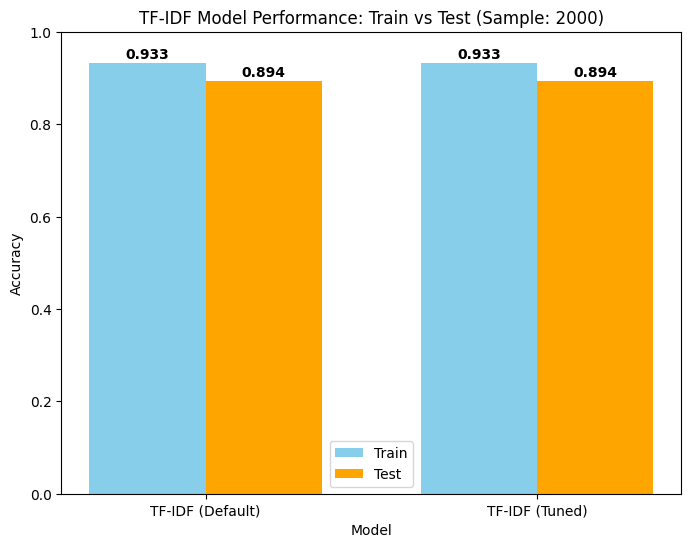

In [9]:
models = ['TF-IDF (Default)', 'TF-IDF (Tuned)']
train_accuracies = []
test_accuracies = []

for i, with_params in enumerate([False, True]):    
    y_train_pred = [predict_sentiment_tfidf(r['contents'], with_params=with_params) 
                    for r in train_sample]
    y_train_true = [r['type'] for r in train_sample]
    train_acc = sum([yt == yp for yt, yp in zip(y_train_true, y_train_pred)]) / len(y_train_true)
    train_accuracies.append(train_acc)
    y_test_pred = [predict_sentiment_tfidf(r['contents'], with_params=with_params) 
                   for r in test_sample]
    y_test_true = [r['type'] for r in test_sample]
    test_acc = sum([yt == yp for yt, yp in zip(y_test_true, y_test_pred)]) / len(y_test_true)
    test_accuracies.append(test_acc)

x = range(len(models))
width = 0.35
plt.figure(figsize=(8, 6))
plt.bar([i - width/2 for i in x], train_accuracies, width, label='Train', color='skyblue')
plt.bar([i + width/2 for i in x], test_accuracies, width, label='Test', color='orange')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title(f'TF-IDF Model Performance: Train vs Test (Sample: {SAMPLE_SIZE})')
plt.xticks(x, models)
plt.legend()
plt.ylim(0, 1)

for i, (train_acc, test_acc) in enumerate(zip(train_accuracies, test_accuracies)):
    plt.text(i - width/2, train_acc + 0.01, f'{train_acc:.3f}', ha='center', fontweight='bold')
    plt.text(i + width/2, test_acc + 0.01, f'{test_acc:.3f}', ha='center', fontweight='bold')

plt.show()

### Accuracy by Review Length
This analysis breaks down TF-IDF model performance based on review length categories. Short reviews have fewer than 100 words, medium reviews have 100-300 words, and long reviews have over 300 words. The chart shows whether TF-IDF models struggle more with brief reviews that lack context or longer reviews that may contain mixed sentiments. Light blue bars represent the Default model while light green bars show the Tuned model performance.

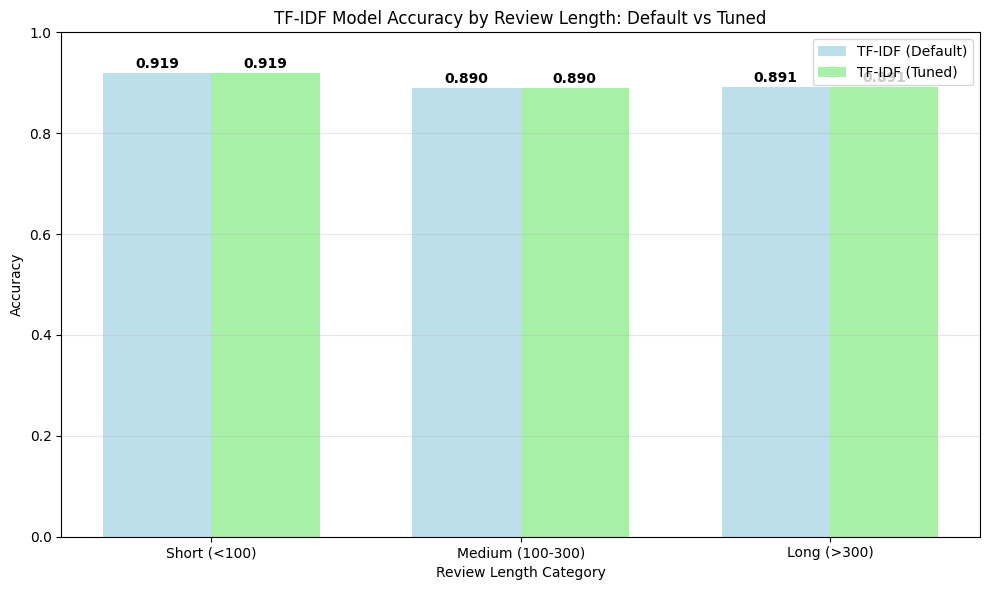


Short (<100) words (247 reviews):
  Default Model: 0.919
  Tuned Model:   0.919
  Improvement:   +0.000

Medium (100-300) words (1312 reviews):
  Default Model: 0.890
  Tuned Model:   0.890
  Improvement:   +0.000

Long (>300) words (441 reviews):
  Default Model: 0.891
  Tuned Model:   0.891
  Improvement:   +0.000


In [10]:
length_analysis_default = {'short': [], 'medium': [], 'long': []}
length_analysis_tuned = {'short': [], 'medium': [], 'long': []}
predictions_correct_default = {'short': [], 'medium': [], 'long': []}
predictions_correct_tuned = {'short': [], 'medium': [], 'long': []}

for r in test_sample:
    length = len(r['contents'].split())
    
    pred_default = predict_sentiment_tfidf(r['contents'], with_params=False)
    pred_tuned = predict_sentiment_tfidf(r['contents'], with_params=True)
    
    correct_default = 1 if pred_default == r['type'] else 0
    correct_tuned = 1 if pred_tuned == r['type'] else 0
    
    if length < 100:
        length_analysis_default['short'].append(length)
        length_analysis_tuned['short'].append(length)
        predictions_correct_default['short'].append(correct_default)
        predictions_correct_tuned['short'].append(correct_tuned)
    elif length < 300:
        length_analysis_default['medium'].append(length)
        length_analysis_tuned['medium'].append(length)
        predictions_correct_default['medium'].append(correct_default)
        predictions_correct_tuned['medium'].append(correct_tuned)
    else:
        length_analysis_default['long'].append(length)
        length_analysis_tuned['long'].append(length)
        predictions_correct_default['long'].append(correct_default)
        predictions_correct_tuned['long'].append(correct_tuned)

categories = ['Short (<100)', 'Medium (100-300)', 'Long (>300)']
accuracies_default = []
accuracies_tuned = []

for cat in ['short', 'medium', 'long']:
    if predictions_correct_default[cat]:
        acc_default = sum(predictions_correct_default[cat]) / len(predictions_correct_default[cat])
        accuracies_default.append(acc_default)
    else:
        accuracies_default.append(0)
    
    if predictions_correct_tuned[cat]:
        acc_tuned = sum(predictions_correct_tuned[cat]) / len(predictions_correct_tuned[cat])
        accuracies_tuned.append(acc_tuned)
    else:
        accuracies_tuned.append(0)

x = range(len(categories))
width = 0.35

plt.figure(figsize=(10, 6))
bars1 = plt.bar([i - width/2 for i in x], accuracies_default, width, 
                label='TF-IDF (Default)', color='lightblue', alpha=0.8)
bars2 = plt.bar([i + width/2 for i in x], accuracies_tuned, width, 
                label='TF-IDF (Tuned)', color='lightgreen', alpha=0.8)

plt.xlabel('Review Length Category')
plt.ylabel('Accuracy')
plt.title('TF-IDF Model Accuracy by Review Length: Default vs Tuned')
plt.xticks(x, categories)
plt.legend()
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)

for i, (acc_default, acc_tuned) in enumerate(zip(accuracies_default, accuracies_tuned)):
    plt.text(i - width/2, acc_default + 0.01, f'{acc_default:.3f}', 
             ha='center', fontweight='bold', fontsize=10)
    plt.text(i + width/2, acc_tuned + 0.01, f'{acc_tuned:.3f}', 
             ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

for i, category in enumerate(categories):
    cat_key = ['short', 'medium', 'long'][i]
    count = len(predictions_correct_default[cat_key])
    print(f"\n{category} words ({count} reviews):")
    print(f"  Default Model: {accuracies_default[i]:.3f}")
    print(f"  Tuned Model:   {accuracies_tuned[i]:.3f}")
    print(f"  Improvement:   {accuracies_tuned[i] - accuracies_default[i]:+.3f}")